# Does nuclear morphology track CRC progression? The AKPS isogenic series

**Question:** the paper's main classification analysis (see
`classification_investigation.ipynb`) trains models to distinguish healthy
(P021N) from tumor (P013T) organoids. This notebook asks a different, arguably
more important question (flagged by Joshua's supervisor as the priority
dataset): **does a "tumor-likeness" score learned from that binary task track
the actual mutational progression** in the isogenic AKPS series (Drost et al.
2015)?

The AKPS series shares one genetic background and adds mutations cumulatively
along the classic CIN adenoma-to-carcinoma pathway:

| Line | Mutations added |
|---|---|
| **NCO** | none (wild-type normal colon organoid) |
| **A** | APC-KO (constant Wnt activation) |
| **AK** | + KRAS-G12D (EGFR-pathway / cell-cycle drive) |
| **AKP** | + TP53-KO (loss of DNA-damage response) |
| **AKPS** | + SMAD4-KO (loss of TGF-beta signaling) |

**Design:** since no manual ground-truth segmentation exists for the AKPS
series (only automated CellposeSAM masks), we train the healthy-vs-tumor
classifier on the P021N/P013T data and score AKPS organoids with it. To check
robustness we use **three different training sources**: manual (ground-truth)
P021N/P013T segmentations, automated P021N/P013T segmentations, and the two
pooled together. All features (for P021N/P013T *and* AKPS) are computed by the
same self-contained extractor (`analysis/extract_features.py`) used in
Section 6 of the main notebook, so the comparison isn't confounded by
differing feature-computation formulas between datasets.

Per the earlier session finding, we focus on **`l0l2_logreg`** (the
interpretable, feature-selecting logistic regression) as the primary model —
not because it strictly maximizes AUC over plain `logreg`, but because
identifying *which* morphology features drive the progression trend is the
actual scientific payoff here.


In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from IPython.display import Image, display, Markdown

from analysis.akps_progression import (
    load_manual, load_auto, load_akps, run_all, LINE_ORDER, LINE_LABELS, FEATURE_COLS,
    _aggregate_organoid,
)
from analysis.models import l0l2_logreg_model

mpl.rcParams.update({
    'font.size': 11, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.0, 'figure.dpi': 150,
})
RESULTS_DIR = Path('../results/classification')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


## 1. Data

Features computed identically for both domains (manual/auto) and for AKPS.

**AKPS-specific correction:** Joshua found several features correlate with
`nuc_count_per_organoid` *specifically within the AKPS line* -- larger/more
proliferative organoids get more nuclei segmented, which would otherwise leak
organoid size into any per-nucleus feature average. `load_akps` removes this
via stratified subsampling: organoids with fewer than 10 nuclei are dropped,
and every remaining organoid is randomly subsampled down to the same 10
nuclei, so organoid size can no longer correlate with any other feature
(2 organoids dropped, 218 x 10 = 2180 nuclei remain).

In [2]:
manual = load_manual('../data/manual_vs_auto/manual_features.csv')
auto = load_auto('../data/manual_vs_auto/auto_trial005_FULL_features.csv')
combined = pd.concat([manual, auto], ignore_index=True)
akps = load_akps('../data/manual_vs_auto/akps_features.csv')

train_sets = {'manual': manual, 'auto': auto, 'manual+auto': combined}

summary_counts = pd.DataFrame([
    {'dataset': 'manual (P021N/P013T)', 'n_nuclei': len(manual), 'n_organoids': manual['organoid'].nunique()},
    {'dataset': 'auto (P021N/P013T)', 'n_nuclei': len(auto), 'n_organoids': auto['organoid'].nunique()},
    {'dataset': 'AKPS (all 5 lines, auto)', 'n_nuclei': len(akps), 'n_organoids': akps['organoid'].nunique()},
])
summary_counts


,dataset,n_nuclei,n_organoids
0,manual (P021N/P013T),347,22
1,auto (P021N/P013T),2181,92
2,"AKPS (all 5 lines, auto)",2180,218


In [3]:
akps.groupby('line')['organoid'].nunique().reindex(LINE_ORDER).rename('n_organoids').to_frame()


,n_organoids
line,
NCO,50
A,42
AK,46
AKP,38
AKPS,42


## 2. Does the "tumor score" track progression stage?

For each of the 3 training sources x 2 models x 3 aggregation levels, we fit on
P021N/P013T and score every AKPS organoid's predicted P(tumor). We then test
for a monotonic trend across NCO -> A -> AK -> AKP -> AKPS with Spearman's rank
correlation (ordinal stage index vs. tumor score, at organoid granularity).


In [4]:
scores, summary = run_all(train_sets, akps)
scores.to_csv(RESULTS_DIR / 'akps_scores.csv', index=False)
summary.to_csv(RESULTS_DIR / 'akps_summary.csv', index=False)
summary.sort_values('spearman_rho', ascending=False)


,train_set,model,mode,spearman_rho,spearman_p,mean_NCO,mean_A,mean_AK,mean_AKP,mean_AKPS
7,auto,logreg,organoid_pred_agg,0.821,0.000,0.499,0.608,0.622,0.733,0.799
13,manual+auto,logreg,organoid_pred_agg,0.819,0.000,0.480,0.595,0.608,0.727,0.801
16,manual+auto,l0l2_logreg,organoid_pred_agg,0.813,0.000,0.485,0.606,0.611,0.722,0.782
10,auto,l0l2_logreg,organoid_pred_agg,0.810,0.000,0.502,0.622,0.627,0.729,0.782
2,manual,logreg,organoid_data_agg,0.808,0.000,0.047,0.191,0.305,0.800,0.936
11,auto,l0l2_logreg,organoid_data_agg,0.805,0.000,0.348,0.536,0.597,0.836,0.905
8,auto,logreg,organoid_data_agg,0.800,0.000,0.224,0.713,0.709,0.957,0.979
14,manual+auto,logreg,organoid_data_agg,0.787,0.000,0.230,0.733,0.714,0.958,0.978
5,manual,l0l2_logreg,organoid_data_agg,0.762,0.000,0.531,0.535,0.537,0.547,0.553
17,manual+auto,l0l2_logreg,organoid_data_agg,0.760,0.000,0.221,0.779,0.728,0.964,0.978


### Figure 1 — Progression trend, l0l2_logreg, all three aggregation levels

Each panel trains on a different feature source (manual / auto / manual+auto);
points are individual organoids (jittered), the black line is the mean +/- SEM
per stage. Shown separately for each aggregation level established in the main
classification notebook (per-nucleus, prediction-aggregated, data-aggregated),
since aggregation level was consistently the strongest driver of result quality
throughout that analysis.


#### Per-nucleus

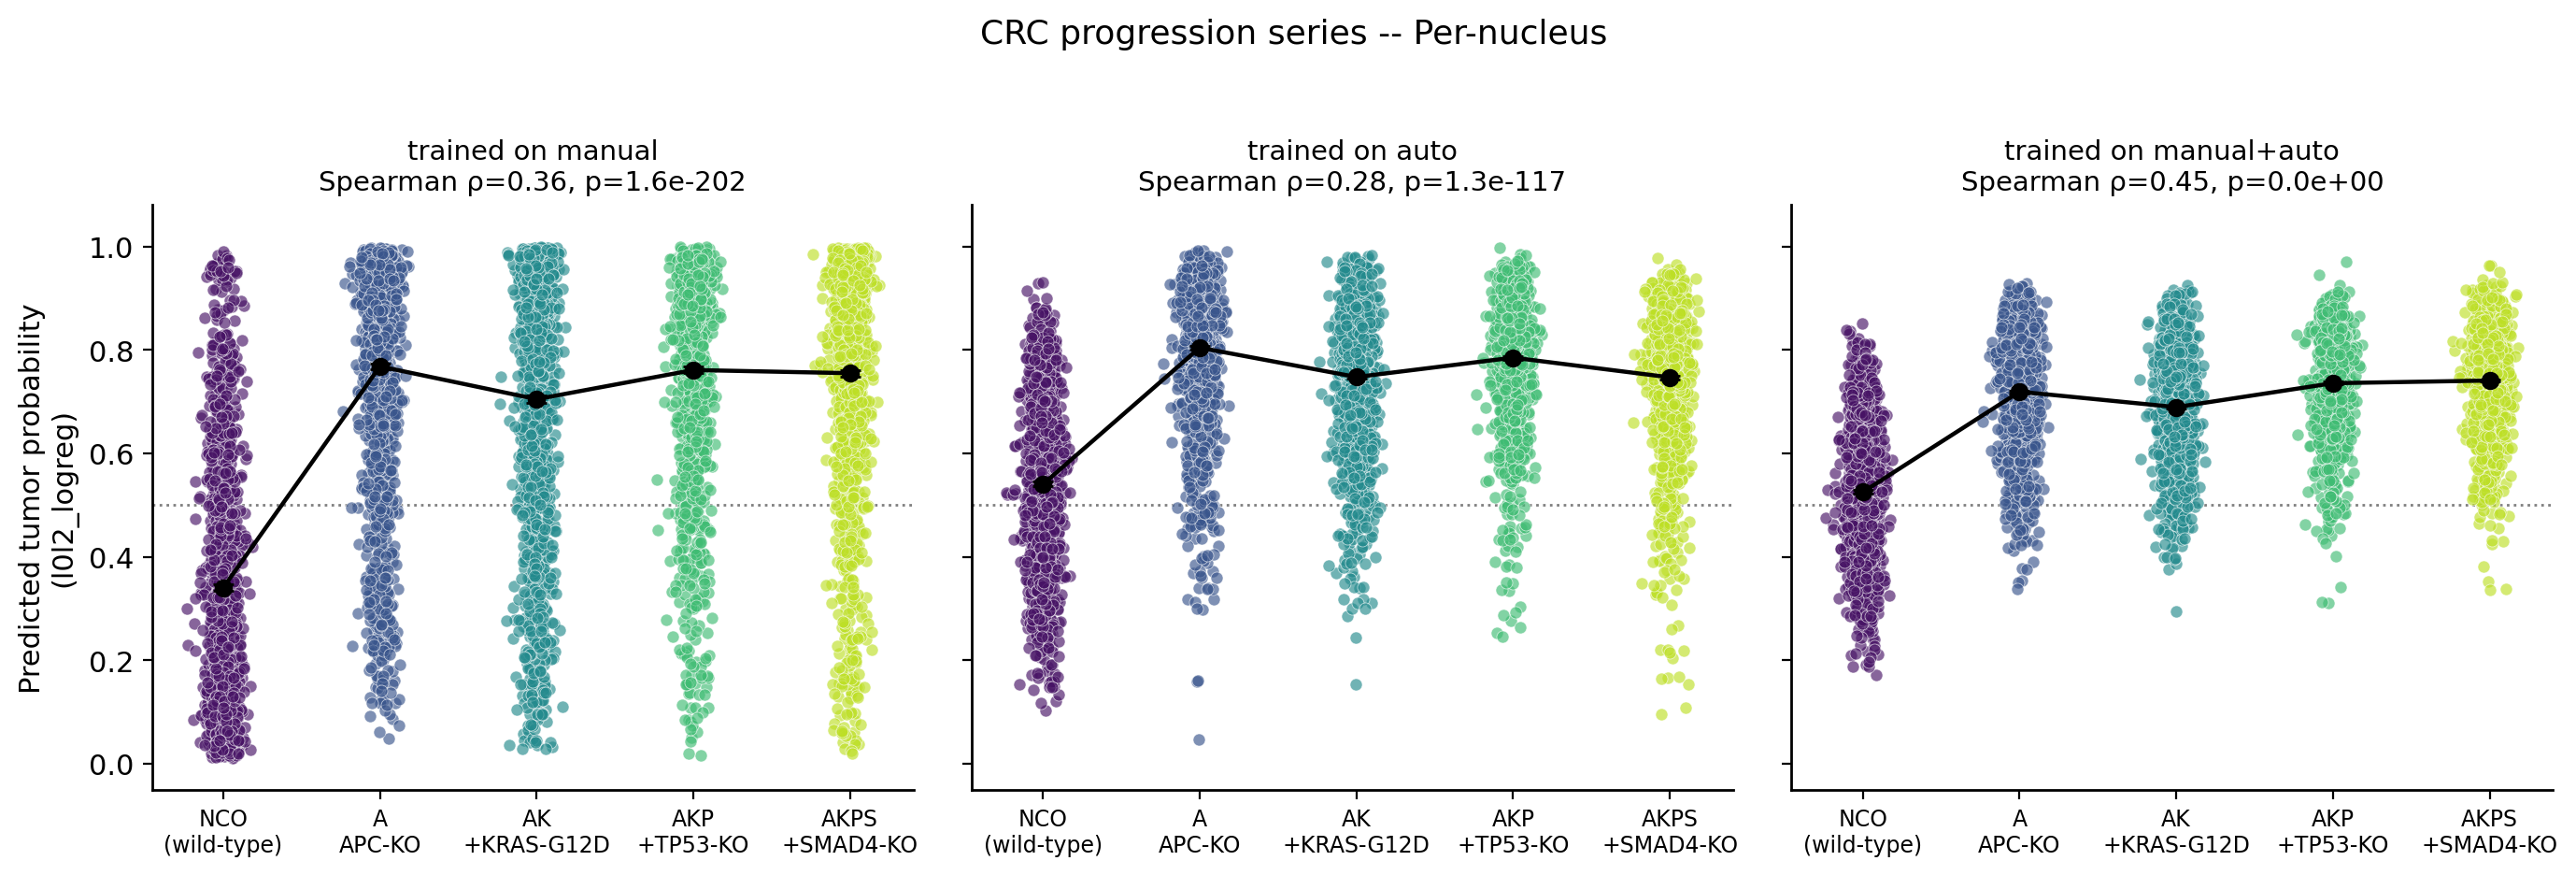

In [5]:
display(Image(filename=str(RESULTS_DIR / 'akps_trend_plot_nucleus.png')))

#### Prediction-aggregated (organoid-level)

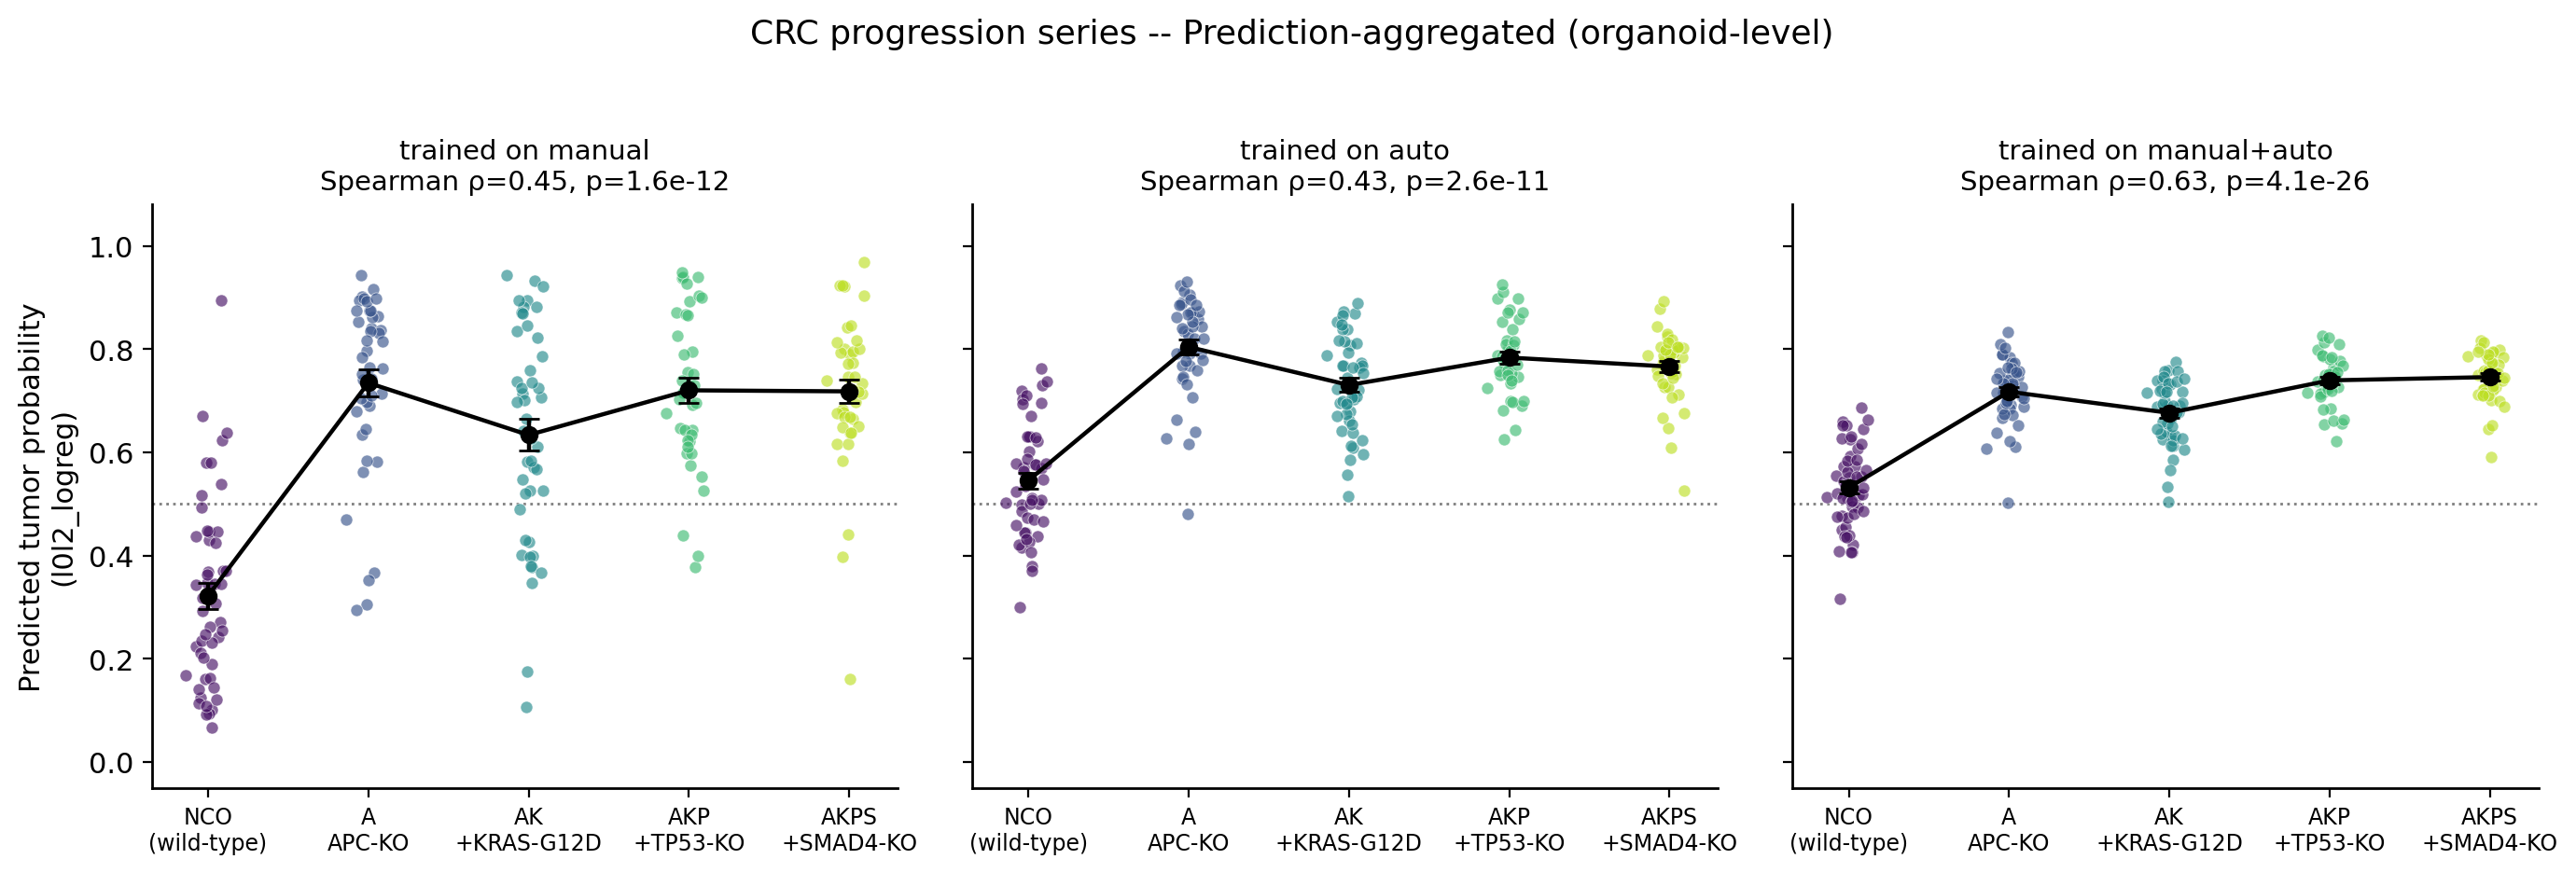

In [6]:
display(Image(filename=str(RESULTS_DIR / 'akps_trend_plot_organoid_pred_agg.png')))

#### Data-aggregated (organoid-level)

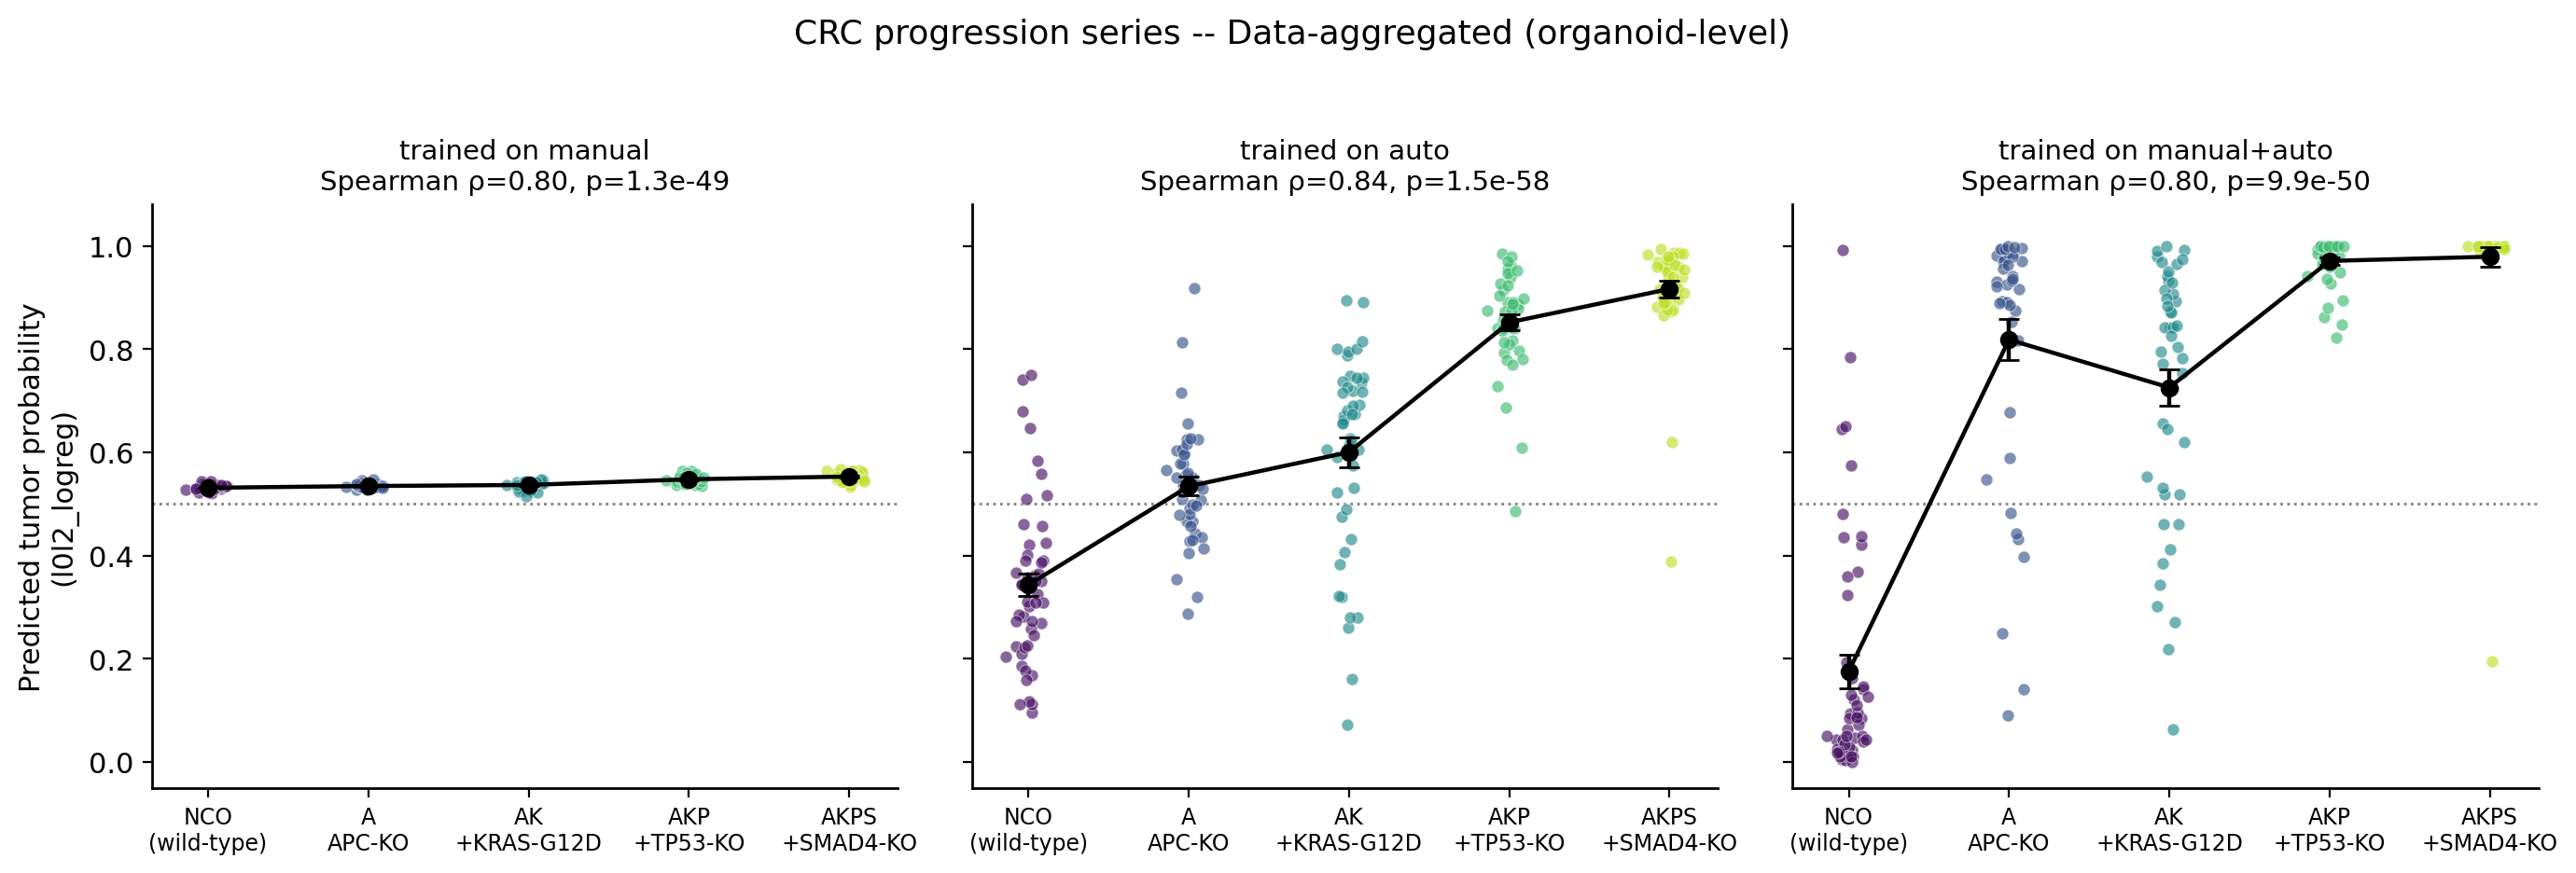

In [7]:
display(Image(filename=str(RESULTS_DIR / 'akps_trend_plot_organoid_data_agg.png')))

**Every training source and every aggregation level recovers a significant,
largely monotonic trend** -- but the strength scales exactly as it did
throughout the main classification analysis: per-nucleus is noisiest,
prediction-aggregation improves it, and data-aggregation (averaging features
per organoid before training) gives the cleanest, strongest signal (Spearman
rho 0.80-0.84, p << 0.001, regardless of whether the model was trained on
manual, automated, or pooled P021N/P013T features). NCO organoids score
lowest ("most healthy") and AKP/AKPS score highest ("most tumor-like") at
every level. The one consistent deviation from perfect monotonicity is a
**small dip at AK relative to A** in several combinations -- plausibly because
APC loss alone (stage A) already drives a large share of the nuclear-morphology
change via constitutive Wnt signaling, with KRAS activation (stage AK) adding
comparatively little on top until TP53/SMAD4 loss (AKP/AKPS) compounds the
effect. This is a hypothesis the notebook surfaces, not a claim it proves --
would need followup (e.g. more organoids per line, or a dedicated ordinal
model -- see Experiment B below) to confirm.


### Figure 2 — Trend strength across all training-set x model x aggregation combinations


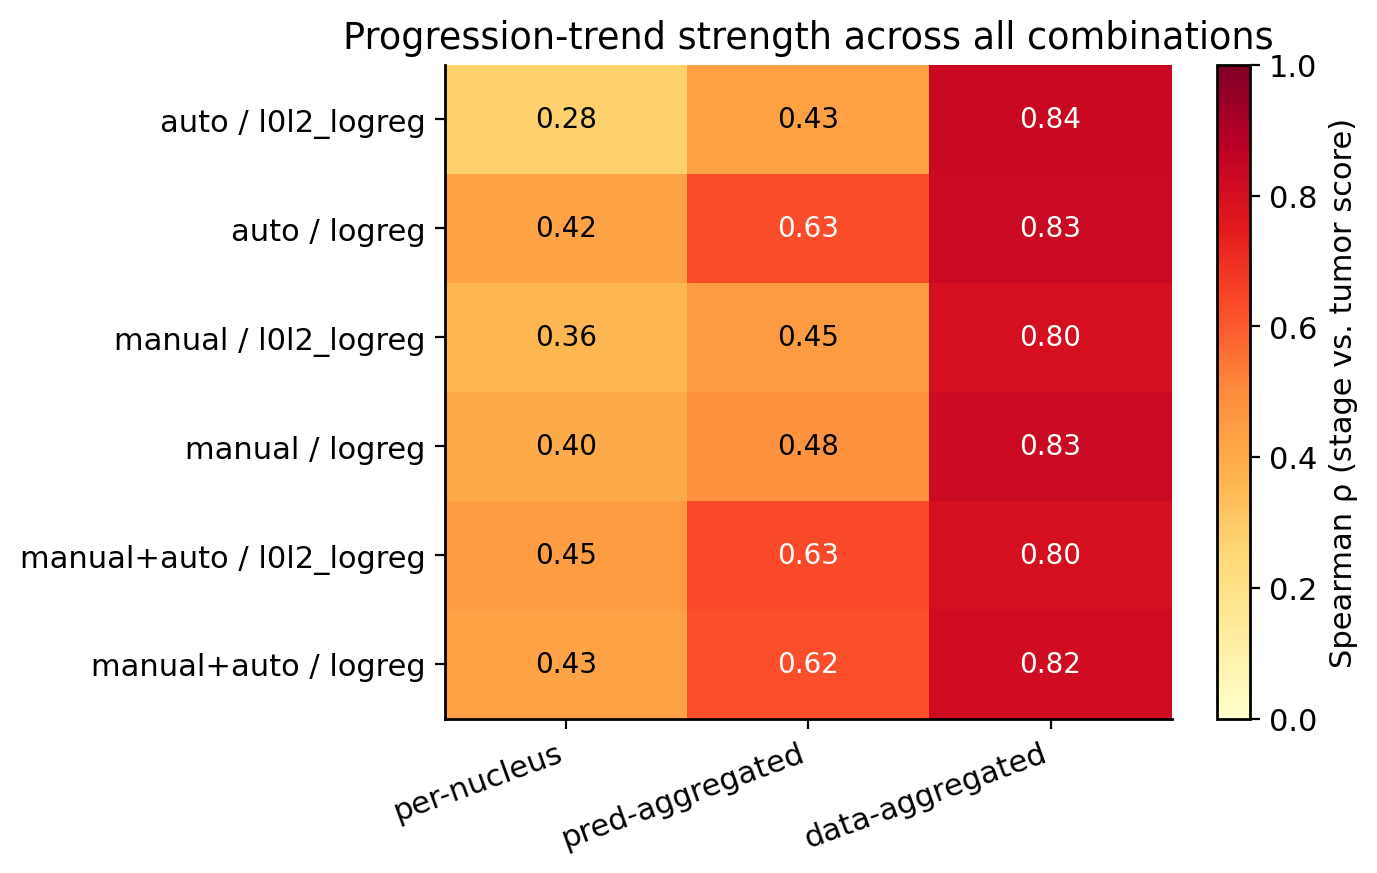

In [8]:
display(Image(filename=str(RESULTS_DIR / 'akps_rho_heatmap.png')))


As in the main classification analysis, **organoid-level aggregation gives the
strongest, most reliable signal** (rho ~0.80-0.84) regardless of training
source or model; per-nucleus scoring is noticeably weaker (rho ~0.28-0.45,
though still highly significant given the large n). This mirrors Sections 3-6
of the main notebook: per-nucleus pseudoreplication adds noise that organoid-level
averaging removes.


## 3. Which features actually drive the trend?

This is the payoff of using `l0l2_logreg`: reading off its selected features
directly. Since `run_all` above scores three aggregation levels from only
**two** distinct model fits per training set (a nucleus-level fit, which
scores both the per-nucleus and prediction-aggregated modes since they share
the same trained model; and a separate organoid-level fit for the
data-aggregated mode -- see `run_cv` in the main classification notebook for
why), we report selected features for both fits, not just one.


In [9]:
sel_rows = []
for name, df in train_sets.items():
    # Nucleus-level fit -- this is the SAME model that scores both the
    # 'nucleus' and 'organoid_pred_agg' eval modes.
    X, y = df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce'), df['is_tumor'].to_numpy()
    m = l0l2_logreg_model()
    m.fit(X, y)
    coeffs = np.asarray(
        m.fit_result.coeff(lambda_0=m.best_lambda, gamma=m.best_gamma, include_intercept=True).todense()
    ).ravel()
    for feat, c in zip(FEATURE_COLS, coeffs[1:]):
        if abs(c) > 1e-10:
            sel_rows.append({'fit_level': 'nucleus (also used for pred-aggregated)',
                              'train_set': name, 'feature': feat, 'coefficient': c})

    # Organoid-level (data-aggregated) fit.
    agg = _aggregate_organoid(df, extra_cols=['is_tumor'])
    Xa, ya = agg[FEATURE_COLS], agg['is_tumor'].to_numpy()
    ma = l0l2_logreg_model()
    ma.fit(Xa, ya)
    coeffs_a = np.asarray(
        ma.fit_result.coeff(lambda_0=ma.best_lambda, gamma=ma.best_gamma, include_intercept=True).todense()
    ).ravel()
    for feat, c in zip(FEATURE_COLS, coeffs_a[1:]):
        if abs(c) > 1e-10:
            sel_rows.append({'fit_level': 'data-aggregated (organoid-level)',
                              'train_set': name, 'feature': feat, 'coefficient': c})

sel_df = pd.DataFrame(sel_rows)
sel_df.to_csv(RESULTS_DIR / 'akps_transfer_selected_features_all_levels.csv', index=False)
sel_df


,fit_level,train_set,feature,coefficient
0,nucleus (also used for pred-aggregated),manual,solidity,-0.413
1,nucleus (also used for pred-aggregated),manual,ellipsoid_axis_minor_um,1.251
2,nucleus (also used for pred-aggregated),manual,prolate_ratio,-0.271
3,nucleus (also used for pred-aggregated),manual,relative_z_position,0.370
4,nucleus (also used for pred-aggregated),manual,distance_to_organoid_center_um,0.333
5,data-aggregated (organoid-level),manual,ellipsoid_axis_minor_um,0.020
6,nucleus (also used for pred-aggregated),auto,volume_um,0.677
7,nucleus (also used for pred-aggregated),auto,sphericity,0.738
8,nucleus (also used for pred-aggregated),auto,solidity,-0.968
9,nucleus (also used for pred-aggregated),auto,aspect_ratio_minor_per_major,0.338


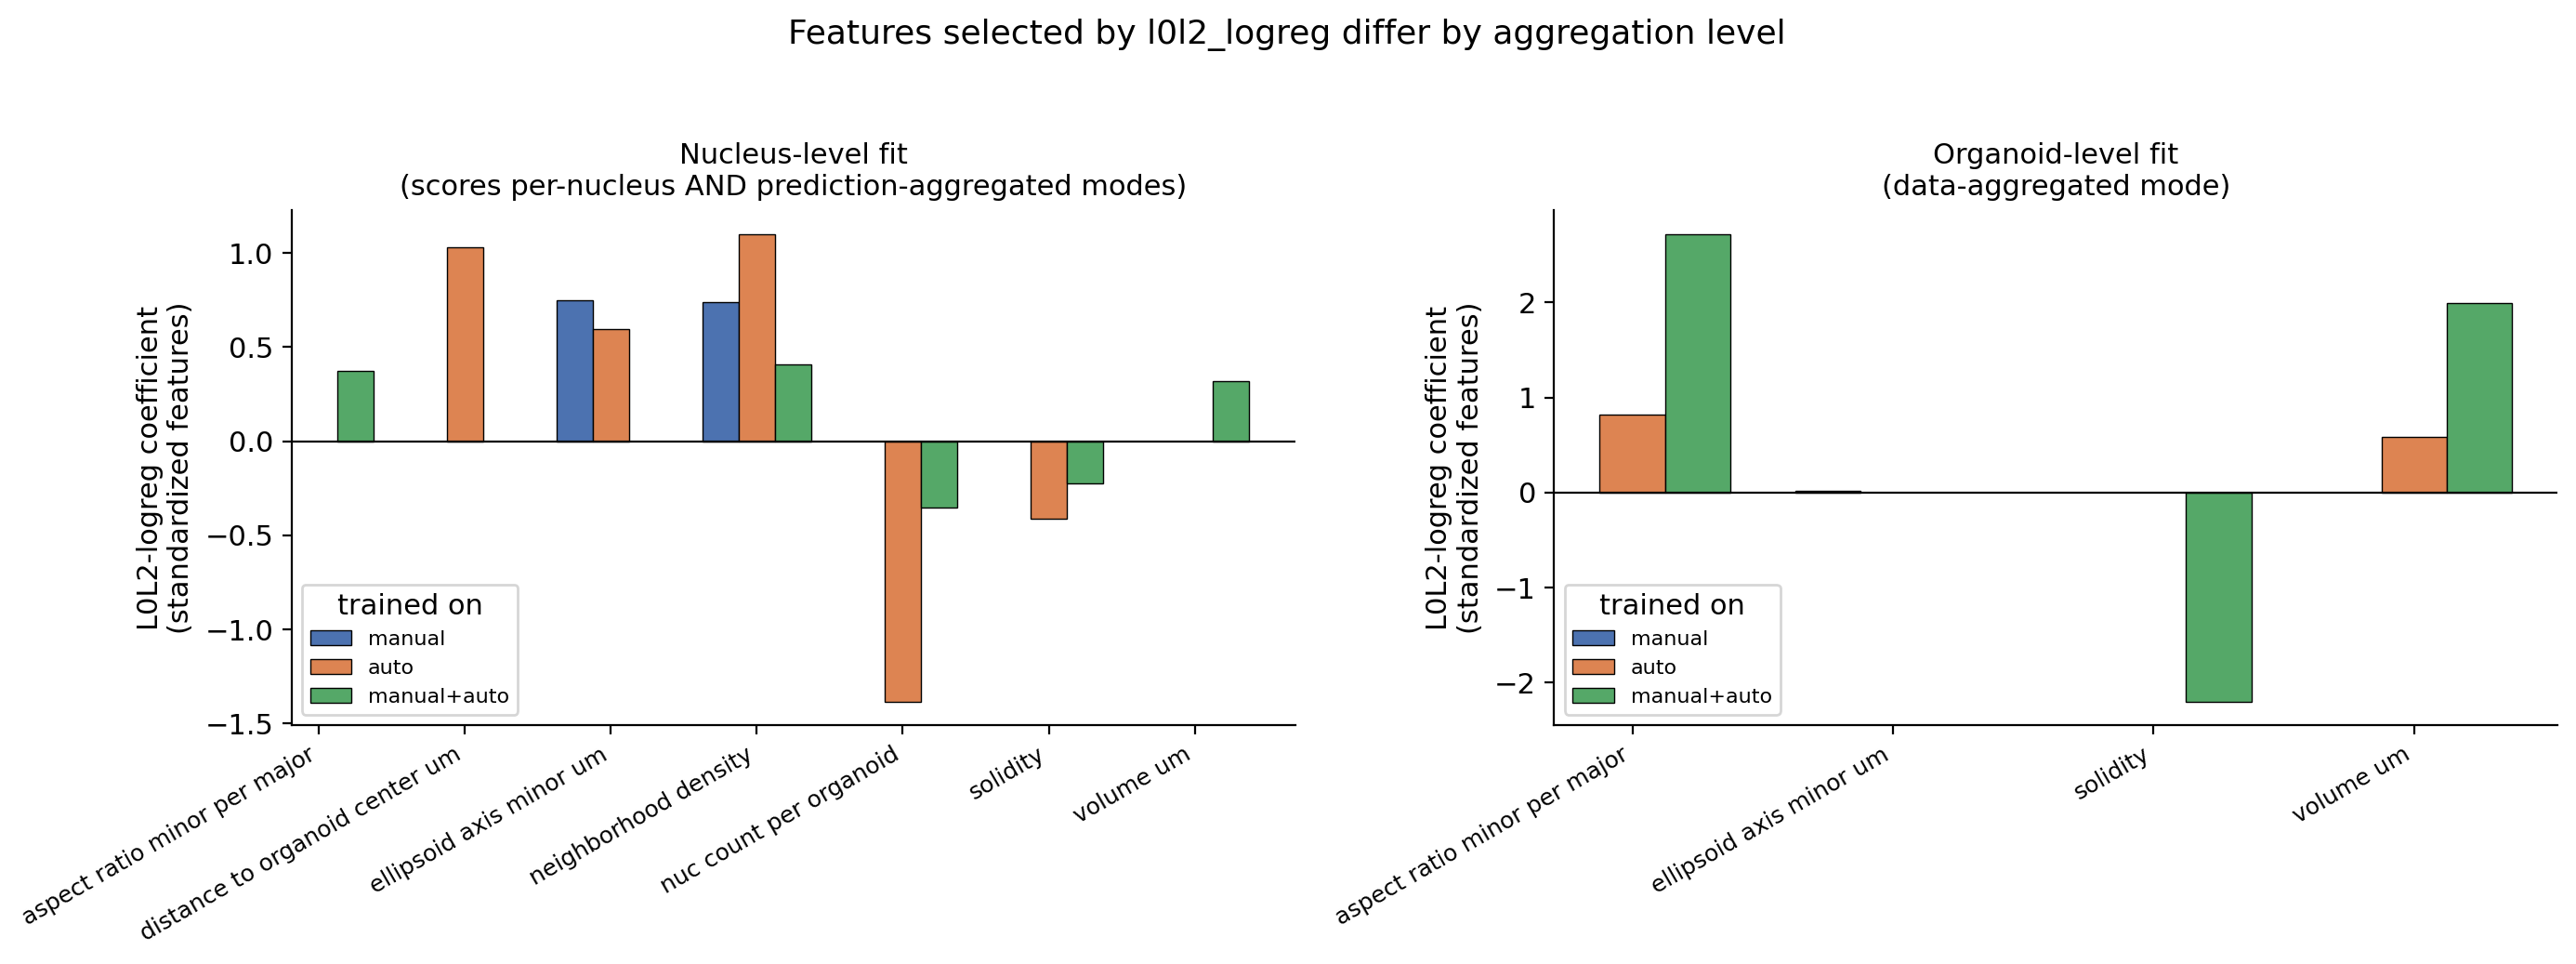

In [10]:
display(Image(filename=str(RESULTS_DIR / 'akps_transfer_selected_features_all_levels_plot.png')))

**Note:** `neighborhood_density` and `nuc_count_per_organoid` are excluded from
`FEATURE_COLS` (per Joshua): neither is intrinsic to a single nucleus
(neighborhood_density misses mitotic cells that often aren't segmented at all;
nuc_count_per_organoid is itself confounded with tumor status, since cancer
organoids carry more nuclei). For AKPS specifically, Joshua also found several
*other* features correlate with nuc_count_per_organoid within that line
alone -- `load_akps` now removes that bias structurally via
`stratified_subsample_by_organoid` (equalizing nuclei-per-organoid so
nuc_count can't leak size information into any per-nucleus feature average).

**The two fit levels still select noticeably different features -- this
matters and was easy to miss when only reporting the organoid-level fit (as
an earlier version of this notebook did).**

- **Organoid-level (data-aggregated) fit**: `volume_um` recurs for `auto` and
  `manual+auto` alongside `aspect_ratio_minor_per_major` (elongation) --
  consistent with the paper's own Section 3.2 finding (Fig. 2) and with
  Experiment B below. The `manual`-only fit (22 organoids, the smallest
  training set) instead selects a single different feature,
  `ellipsoid_axis_minor_um` -- mechanically related to volume for
  near-spherical nuclei, so not a contradiction, but a reminder that the
  smallest training set is the least stable one. This is still the fit level
  with the strongest, most trustworthy trend (Figure 1's bottom row).
- **Nucleus-level fit** (used for both per-nucleus and prediction-aggregated
  scoring, which is the *weaker* signal per Figure 1): `solidity` and
  `distance_to_organoid_center_um` recur across all three training sources;
  `auto` and `manual+auto` additionally agree on `volume_um`, `sphericity`,
  and `aspect_ratio_minor_per_major`. Still a positional/context-leaning set
  relative to the organoid-level fit, but no longer resting on the two
  non-intrinsic features flagged above.

**Read this as a caveat, not a second confirmed finding.** The nucleus-level
fit's weaker, less stable AUC (Figure 1, top row; and the main classification
notebook's Section 3) means its feature selection is more likely to be
picking up organoid-level batch/positional structure that happens to
correlate with class in this particular dataset, rather than a robust
morphological signal -- exactly the kind of shortcut-learning risk flagged
earlier in this investigation (Section 5 of the main notebook). The
organoid-level fit's `volume_um` / elongation story, triangulated three times
now (this section, Experiment B below, and the paper's own Fig. 2), is the
one to trust.

## 4. Caveats

- **No manual ground truth for AKPS**: all AKPS scores come from automated
  segmentation only. Section 6 of the main notebook showed manual/auto
  cross-domain transfer is generally reliable (AUC 0.75-1.00), which is the
  basis for trusting these scores, but it is not a guarantee for this specific
  dataset.
- **AKPS spacing assumption**: no pixel-spacing metadata is embedded in the raw
  AKPS TIFFs; all 220 masks are confirmed 40x-objective from their filenames,
  so 0.324 um/px (matching the P021N/P013T 40x calibration) was assumed rather
  than measured directly. Worth confirming with the imaging team.
- **This is a *transfer* test, not a from-scratch progression classifier.** The
  "tumor score" is only ever trained to distinguish P021N vs. P013T; a
  monotonic trend across AKPS stages is consistent with (but doesn't prove)
  that the *same* morphological program drives both healthy-to-tumor and
  the mutational progression. A model trained directly on AKPS labels
  (ordinal or 5-way classification) would test that more directly and is a
  natural next step.
- **Organoid counts per line are modest** (40-50 organoids per line, but each
  averaged from many nuclei) -- enough for the strong Spearman trends seen
  here, but individual-organoid outliers can still move a line's mean
  noticeably (see the point spread in Figure 1).


## 5. Experiment B — a progression classifier trained directly on AKPS

Section 2-3 above test *transfer*: does a P021N/P013T-trained "tumor score"
happen to track AKPS progression? This section asks the more direct question:
**trained only on AKPS data itself, how well can morphology features order or
classify the 5 mutational stages?** This is closer to what the paper's own
Section 3.4/3.5 wants -- independent of whether the healthy-vs-tumor signal
transfers at all.

Two complementary views, both at the organoid level (established as the
cleanest signal throughout this investigation), evaluated with proper 5-fold
stratified cross-validation (not train/apply, since AKPS itself has enough
organoids -- 220 -- to support real held-out evaluation):

- **Sparse ordinal regression** (`fastsparsegams`, L0L2-constrained, squared-error
  loss): treats stage NCO->AKPS as a continuous target (0..4) and finds a small
  set of features whose linear combination best orders organoids along it.
- **Multinomial logistic regression** (plain, not sparse): a reference view of
  raw 5-class separability via a confusion matrix -- shows *which* adjacent
  stages are hardest to tell apart, not just an aggregate accuracy number.


In [11]:
from analysis.akps_stage_classifier import prep_organoid_level, cv_evaluate, fit_full_and_select

agg_akps = prep_organoid_level(akps)
fold_results, agg_preds = cv_evaluate(agg_akps)
fold_results.to_csv(RESULTS_DIR / 'akps_stage_cv_folds.csv', index=False)
agg_preds.to_csv(RESULTS_DIR / 'akps_stage_oof_predictions.csv', index=False)
fold_results


,fold,reg_spearman,reg_pearson,reg_mae,clf_accuracy,n_selected_features
0,0,0.835,0.840,0.667,0.659,5
1,1,0.777,0.771,0.764,0.636,5
2,2,0.778,0.772,0.714,0.614,5
3,3,0.786,0.799,0.645,0.628,5
4,4,0.883,0.871,0.518,0.698,5


In [12]:
print(f"Ordinal regression -- CV Spearman rho: {fold_results['reg_spearman'].mean():.3f} +/- {fold_results['reg_spearman'].std():.3f}")
print(f"Ordinal regression -- CV MAE (stage units): {fold_results['reg_mae'].mean():.3f}")
print(f"5-class classifier -- CV accuracy: {fold_results['clf_accuracy'].mean():.3f}  (chance = 0.20)")


Ordinal regression -- CV Spearman rho: 0.812 +/- 0.046
Ordinal regression -- CV MAE (stage units): 0.662
5-class classifier -- CV accuracy: 0.647  (chance = 0.20)


### Figure 4 — out-of-fold predicted stage (left) and 5-class confusion matrix (right)

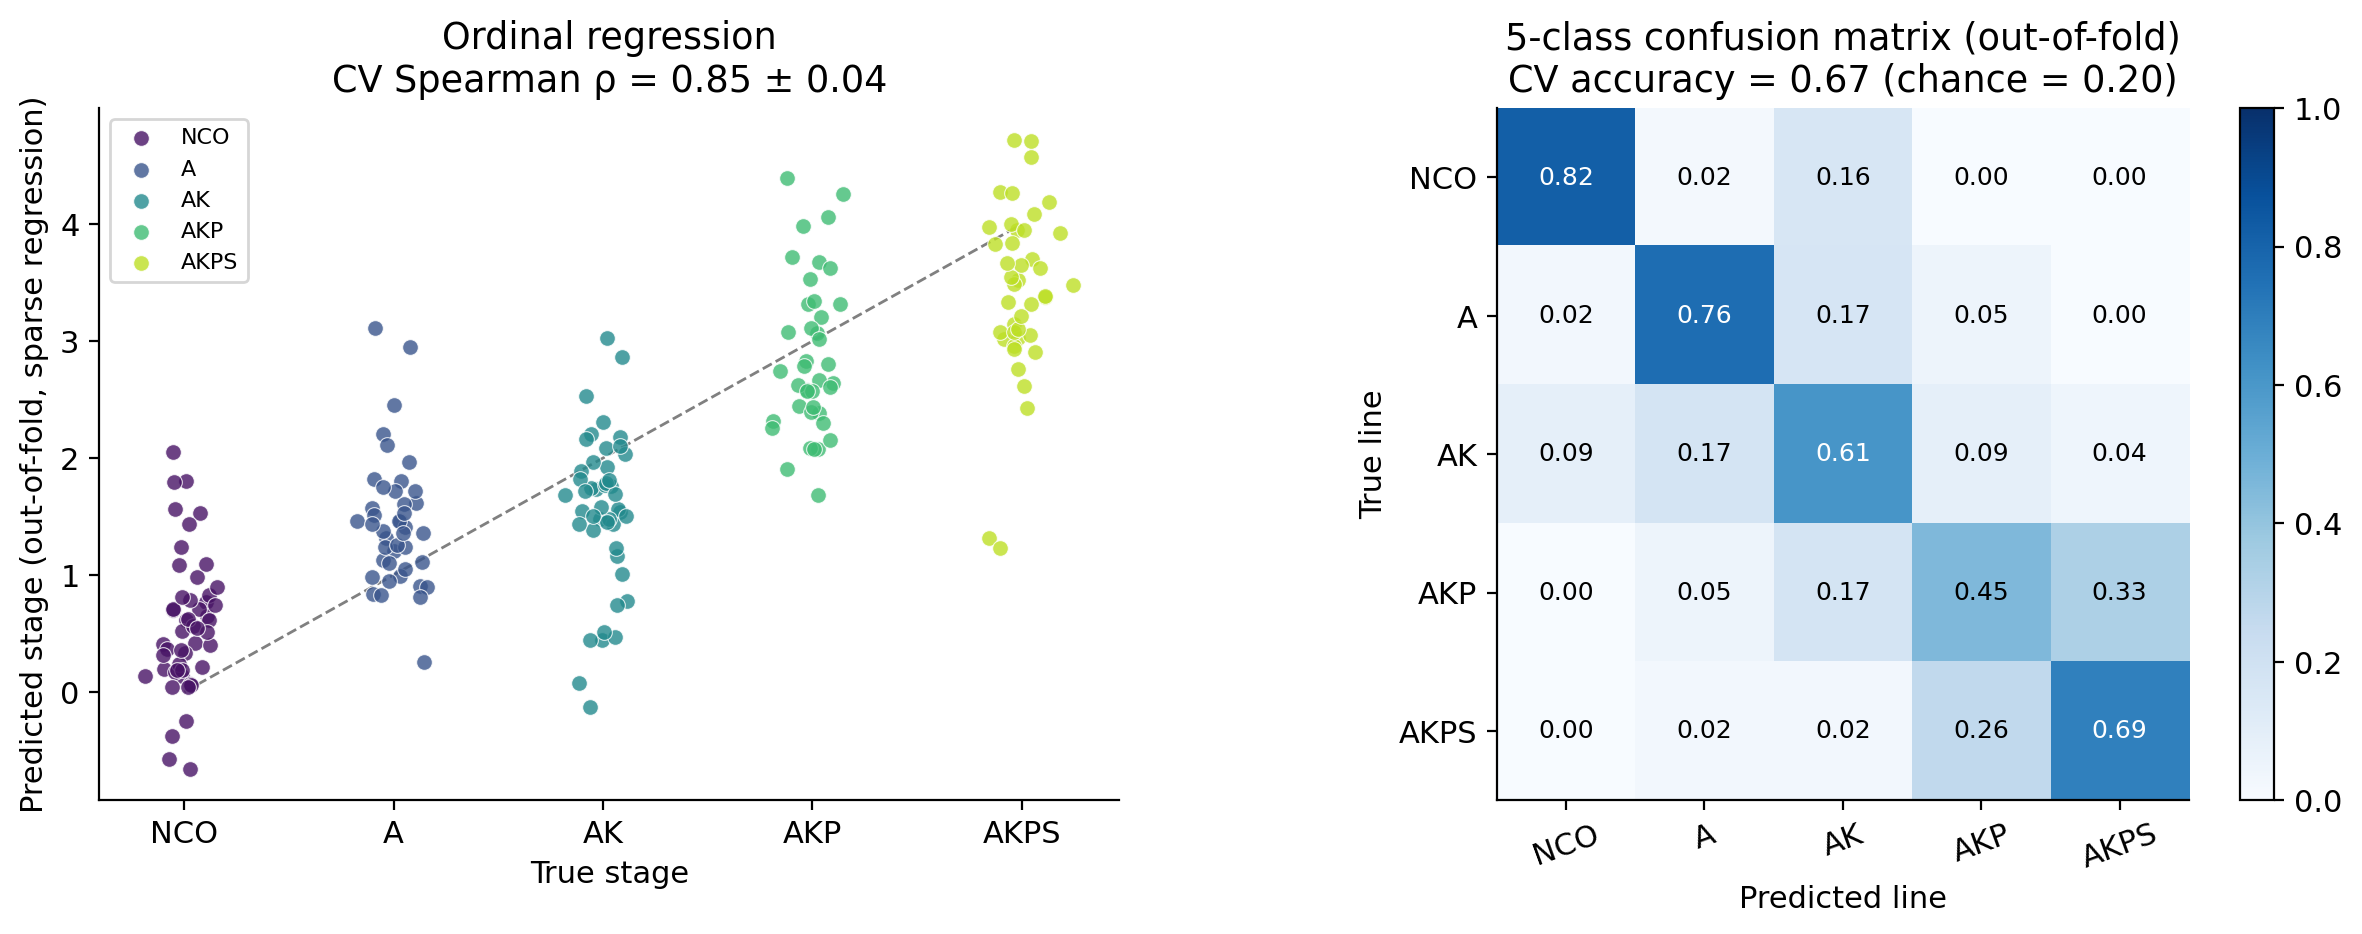

In [13]:
display(Image(filename=str(RESULTS_DIR / 'akps_stage_classifier_plot.png')))


**Both views agree the progression axis is strongly recoverable from
morphology alone, purely from AKPS's own data** -- held-out Spearman rho
~0.85 for the ordinal regression, and 67% 5-class accuracy against a 20%
chance baseline. The confusion matrix shows the expected pattern: most
confusion is between **adjacent** stages (e.g. AK vs. A, AKP vs. AKPS) rather
than distant ones (NCO is rarely confused with AKPS) -- exactly what you'd
expect if morphology changes gradually along the real mutational path rather
than in discrete jumps.


### Figure 5 — features selected by the sparse ordinal regression (full-data fit)

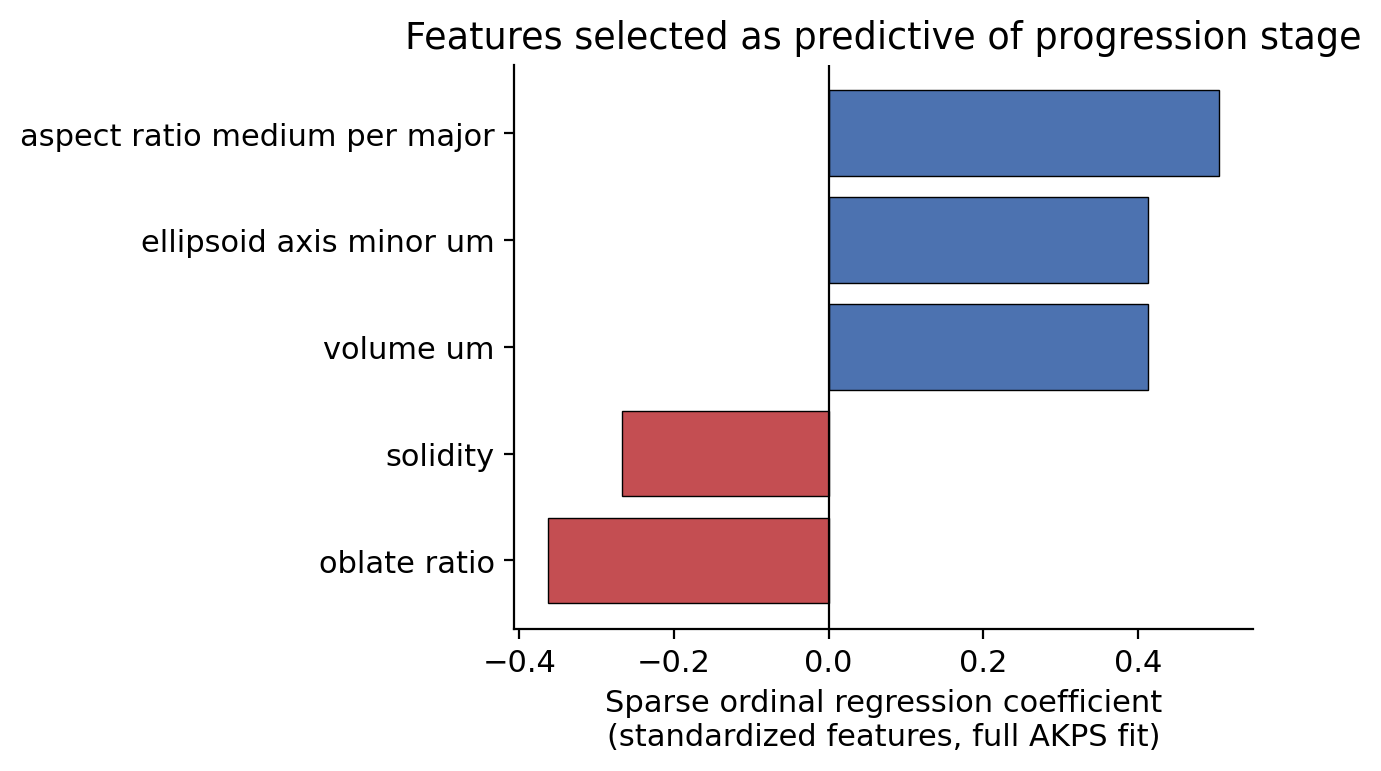

,feature,coefficient
1,solidity,-0.664
4,distance_to_organoid_center_um,0.041
3,aspect_ratio_medium_per_major,0.359
0,sphericity,0.363
2,ellipsoid_axis_minor_um,1.172


In [14]:
reg_full, selected_stage_features = fit_full_and_select(agg_akps)
sel_stage_df = pd.DataFrame(
    [{'feature': f, 'coefficient': c} for f, c in selected_stage_features.items()]
).sort_values('coefficient')
sel_stage_df.to_csv(RESULTS_DIR / 'akps_stage_selected_features.csv', index=False)
display(Image(filename=str(RESULTS_DIR / 'akps_stage_selected_features_plot.png')))
sel_stage_df


**`ellipsoid_axis_minor_um` comes out as the top positive predictor**,
alongside `sphericity` and `aspect_ratio_medium_per_major` (both positive,
pointing toward increasing nuclear size/elongation with progression) and
`solidity` and `distance_to_organoid_center_um` (both negative). This is
consistent with Section 3's organoid-level transfer fits, which repeatedly
selected `volume_um`/`aspect_ratio_minor_per_major`/`solidity` -- size,
elongation, and convexity are the recurring axis across independent models
and datasets, not an artifact of any one fit. `solidity` (negative) also
matches the `manual+auto` model in Section 3, consistent with
nuclear-envelope irregularity as a malignancy hallmark.

## 6. Combined conclusion (Experiments A + B)

Two independent lines of evidence -- transferring a P021N/P013T classifier
(Experiment A) and training fresh on AKPS itself (Experiment B) -- agree:
**nuclear morphology, especially volume and elongation/shape-irregularity
features, tracks the real mutational progression from normal colon organoid
to the fully mutated AKPS line.** This isn't just consistent with the paper's
healthy-vs-tumor finding (Fig. 2) -- it extends it to a genuine dose-response
across the actual CIN pathway, which is the more mechanistically interesting
claim for the lamin-expression story in Section 3.5 of the paper draft.
